# TMDB 5000 영화 데이터 세트
* 영화 데이터 정보 사이트 IMDB의 영화 중 주요 5천개 영화 대한 메타 정보 새롭게 가공 -> Kaggle에 제공

# 장르 속성을 이용한 영화 콘텐츠 기반 필터링
* 영화 간의 유사성을 판단하는 기준이 영화를 구성하는 다양한 콘텐츠를 기반으로 하는 방식
* 장르 칼럼 값의 유사도를 비교한 뒤 그 중 높은 평점을 가지는 영화를 추천

# 데이터 로딩 및 가공

In [2]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

movies = pd.read_csv('../kaggle/tmdb_5000/tmdb_5000_movies.csv')
print(movies.shape)
movies.head(1)

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [3]:
#콘텐츠 기반 필터링 추천 분석에 사용할 주요 칼럼만 추출해 DF 만들기
movies_df = movies[['id', 'title', 'genres', 'vote_average', 'vote_count', 'popularity', 'keywords', 'overview']]

In [4]:
#한 칼럼 내에 여러 개의 요소를 가지는 딕셔너리가 들어가 있는 경우가 있음 -> 문자열로 분리해서 파이썬 리스트 객체로 추출

from ast import literal_eval #문자열이 의미하는 list[dict, dict, ...] 객체로 만들 수 있음

movies_df['genres'] = movies_df['genres'].apply(literal_eval)
movies_df['genres'] = movies_df['genres'].apply(lambda x : [y['name'] for y in x])
movies_df['keywords'] = movies_df['keywords'].apply(literal_eval)
movies_df['keywords'] = movies_df['keywords'].apply(lambda x : [y['name'] for y in x])
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon..."


# 장르 콘텐츠 유사도 측정
* 개별 장르가 리스트로 구성돼 있음 -> 장르별 유사도 측정 방법?
  * 장르를 문자열로 변경함 -> CountVectorizer로 피처화한 행렬 데이터값 -> 코사인 유사도로 비교하는 것이 간단
* 장르 칼럼을 기반으로 하는 콘텐츠 기반 필터링의 단계
  * 문자열로 변환된 장르 칼럼을 count 기반으로 피처 벡터화 변환함
  * 장르 문자열을 피처 벡터화 행렬로 변환한 데이터셋을 코사인 유사도를 통해 비교함. 이를 위해 데이터셋의 레코드별로 타 레코드와 장르에서 코사인 유사도 값을 가지는 객체 생성
  * 장르 유사도가 높은 영화 중 평점 높은 순으로 영화 추천
* 사이킷런 코사인 유사도 cosine_similarities : 기준 행과 비교 행의 코사인 유사도를 행렬 형태로 반환하는 함수
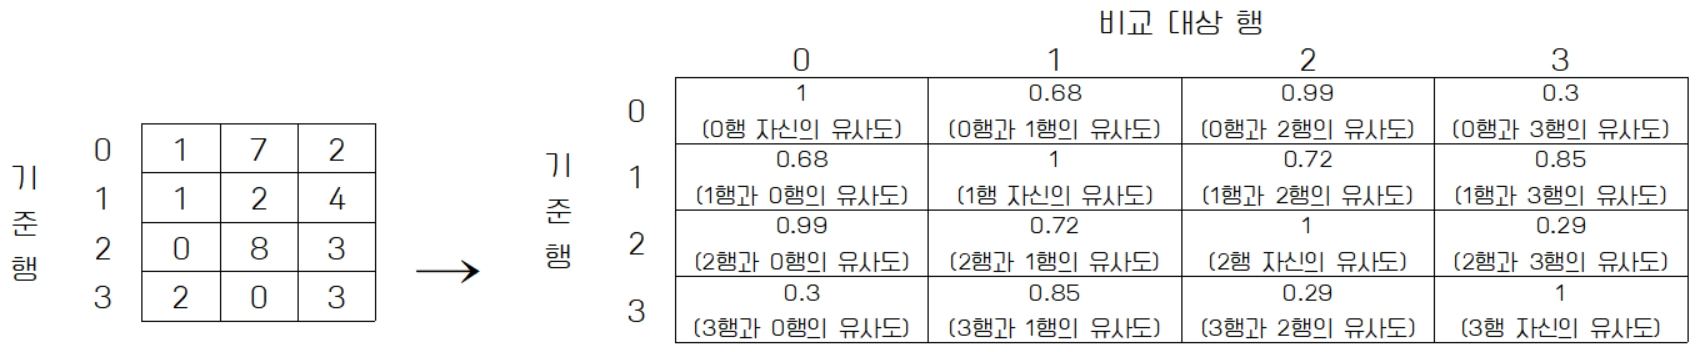

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

### 개별 단어 피처로 구성된 피처 벡터 행렬 만들기
#CountVectorizer를 적용하기 위해 공백문자로 word 단위가 구분되는 문자열로 변환
movies_df['genres_literal'] = movies_df['genres'].apply(lambda x : (' ').join(x))
count_vect = CountVectorizer(min_df=0, ngram_range=(1, 2))
genre_mat = count_vect.fit_transform(movies_df['genres_literal'])
print(genre_mat.shape)

(4803, 276)


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

### 코사인 유사도 계산
genre_sim = cosine_similarity(genre_mat, genre_mat)
print(genre_sim.shape)
print(genre_sim[:1])

(4803, 4803)
[[1.         0.59628479 0.4472136  ... 0.         0.         0.        ]]


* cosine_similarities() 호출로 생성된 genre_sim 객체
  * movies_df의 genre_literal 칼럼을 피처 벡터화한 행렬(genre_mat) 데이터의 행(레코드)별 유사도 정보 가짐
  * movies_df DataFrame의 행별 장르 유사도값 가진 것
* movies_df를 장르 기준으로 콘텐츠 기반 필터링 수행하려면?
  * 개별 레코드 대해 가장 장르 유사도 높은 순으로 다른 레코드 추출해야
  * 이를 위해 genre_sim 객체 이용함
    * genre_sim 객체의 기준 행별로 비교 대상이 되는 행의 유사도 값이 높은 순으로 정렬된 행렬의 위치 인덱스 값을 추출
    * 값이 높은 순으로 정렬된 비교 대상 행 = 유사도 값(X) 비교 대상 행의 위치 인덱스(O)
    * argsort() 함수 이용 : argsort()[:, ::-1] 이용해 유사도 높은 순으로 정리된 genre_sim 객체의 비교 행 위치 인덱스 값을 간편하게 얻음

In [7]:
###높은 순으로 정렬된 비교 행 위치 인덱스 값을 가져옴, 0번 레코드 비교 행 위치 인덱스 값만 샘플로 추출해보자
genre_sim_sorted_idx = genre_sim.argsort()[:, ::-1]
print(genre_sim_sorted_idx[:1])

[[   0 3494  813 ... 3038 3037 2401]]


* 위 반환값이 의미하는 것?
  * 0번 레코드라면, 자신인 0번 레코드를 제외하면 3494번 레코드가 가장 유사도 높음, 그 다음이 813번 레코드, .. 가장 낮은 유사도 레코드는 2401번
* genre_sim_sorted_idx 객체 : 각 레코드의 장르 코사인 유사도가 가장 높은 순으로 정렬된 타 레코드의 위치 인덱스값 가짐
* 이를 이용해 언제든 특정 레코드와 코사인 유사도가 높은 다른 레코드 추출 가능

# 장르 콘텐츠 필터링을 이용한 영화 추천

In [8]:
### 장르 유사도에 따라 영화를 추천하는 함수 생성
def find_sim_movies(df, sorted_idx, title_name, top_n=10):
    #인자로 입력된 df에 타이틀 칼럼이 입력된 title_name 값인 Df 추출
    title_movie = df[df['title']==title_name]
    #title_name가진 DataFrame의 index 객체를 ndarray로 변환 & sorted_idx 인자로 입력된 genre_sim_sorted_idx 객체에서 유사도 순으로 top_n개의 index 추출
    title_index = title_movie.index.values
    similar_indexes = sorted_idx[title_index, :(top_n)]
    #추출된 top_n index 출력. 2차원 데이터임. dataframe에서 index로 사용하려 1차원 배열로 변경
    print(similar_indexes)
    similar_indexes = similar_indexes.reshape(-1)
    
    return df.iloc[similar_indexes]

#위 함수를 이용해 영화 <대부>와 장르별로 유사한 영화 10개 추천해보기
similar_movies = find_sim_movies(movies_df, genre_sim_sorted_idx, 'The Godfather', 10)
similar_movies[['title', 'vote_average']]

[[2731 1243 3636 1946 2640 4065 1847 4217  883 3866]]


,title,vote_average
2731,The Godfather: Part II,8.3
1243,Mean Streets,7.2
3636,Light Sleeper,5.7
1946,The Bad Lieutenant: Port of Call - New Orleans,6.0
2640,Things to Do in Denver When You're Dead,6.7
4065,Mi America,0.0
1847,GoodFellas,8.2
4217,Kids,6.8
883,Catch Me If You Can,7.7
3866,City of God,8.1


* 추천 목록에는 평점이 매우 낮은 등 문제가 있음
* 좀 더 많은 후보군 선정한 뒤, 평점에 따라 필터링해서 최종 추천하는 방식으로 바꾸자
* vote_average : 평점 정보. 여러 관객의 점수를 평균한 것 -> 소수 관객이 특정 영화 고득점 주었을 경우 왜곡된 데이터 가짐

In [9]:
### 평점을 오름차순으로 정렬해 출력해보자 for 왜곡 데이터 판별
movies_df[['title', 'vote_average', 'vote_count']].sort_values('vote_average', ascending=False)[:10]

,title,vote_average,vote_count
3519,Stiff Upper Lips,10.0,1
4247,Me You and Five Bucks,10.0,2
4045,"Dancer, Texas Pop. 81",10.0,1
4662,Little Big Top,10.0,1
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
2970,There Goes My Baby,8.5,2
1881,The Shawshank Redemption,8.5,8205
2796,The Prisoner of Zenda,8.4,11
3337,The Godfather,8.4,5893


* 왜곡된 평점 데이터 회피하고자 평점에 평가 횟수를 반영하는 평가 방식 필요 -> IMDB에서 가중치가 부여된 평점(weighted rating) 방식 사용
* 가중 평점 = {v / (v+m)} * R + {m / (v+m)} * C
  * v = 개별 영화에 평점을 투표한 횟수 -> moives_df 'vote_count'값
  * m = 평점을 부여하기 위한 최소 투표 횟수 -> 투표 횟수 따른 가중치를 직접 조절하는 ㄴ역할. 높이면 평점 투표 횟수 많은 영화 더 많은 가중평점 부여. 전체 투표 횟수에서 60프로 해당하는 횟수를 기준으로 하자
  * R = 개별 영화에 대한 평균 평점 -> vote_average 값
  * C = 전체 영화에대한 평균 평점 -> movies_df['vote_aveage'].mean()

In [10]:
C = movies_df['vote_average'].mean()
m = movies_df['vote_count'].quantile(0.6)
print('C : ', round(C, 3), ' m : ', round(m, 3))

C :  6.092  m :  370.2


In [16]:
percentile = 0.6
m = movies_df['vote_count'].quantile(percentile)
C = movies_df['vote_average'].mean()

### 새로운 가중 평점으로 변경하는 함수
def weighted_vote_average(record):
    v = record['vote_count']
    R = record['vote_average']
    return (v / (v+m)) * R + (m / (v+m)) * C
    
movies_df['weighted_vote'] = movies_df.apply(weighted_vote_average, axis=1)
movies_df[['title', 'vote_average', 'weighted_vote', 'vote_count']].sort_values('weighted_vote', ascending=False)[:10]

,title,vote_average,weighted_vote,vote_count
1881,The Shawshank Redemption,8.5,8.396052,8205
3337,The Godfather,8.4,8.263591,5893
662,Fight Club,8.3,8.216455,9413
3232,Pulp Fiction,8.3,8.207102,8428
65,The Dark Knight,8.2,8.136930,12002
1818,Schindler's List,8.3,8.126069,4329
3865,Whiplash,8.3,8.123248,4254
809,Forrest Gump,8.2,8.105954,7927
2294,Spirited Away,8.3,8.105867,3840
2731,The Godfather: Part II,8.3,8.079586,3338


In [17]:
###장르유사성이 높은 영화를 top-n의 2배수만큼 후보군으로 선정한 뒤, weighted_vote 칼럼이높은 순으로 n만큼 추출
def find_sim_movies(df, sorted_idx, title_name, top_n=10):
    title_movie = df[df['title']==title_name]
    title_index = title_movie.index.values
    
    #top-n의 2배에 해당하는 장르 유사성 높은 인덱스 추출
    similar_indexes = sorted_idx[title_index, :(top_n*2)]
    similar_indexes = similar_indexes.reshape(-1)
    #기준 영화 인덱스는 제외
    similar_indexes = similar_indexes[similar_indexes != title_index]
    
    #weight_vote가 높은 순으로 n만큼 추출
    return df.iloc[similar_indexes].sort_values('weighted_vote', ascending=False)[:top_n]

#위 함수를 이용해 영화 <대부>와 장르별로 유사한 영화 10개 추천해보기
similar_movies = find_sim_movies(movies_df, genre_sim_sorted_idx, 'The Godfather', 10)
similar_movies[['title', 'vote_average', 'weighted_vote']]

,title,vote_average,weighted_vote
2731,The Godfather: Part II,8.3,8.079586
1847,GoodFellas,8.2,7.976937
3866,City of God,8.1,7.759693
1663,Once Upon a Time in America,8.2,7.657811
883,Catch Me If You Can,7.7,7.557097
281,American Gangster,7.4,7.141396
4041,This Is England,7.4,6.739664
1149,American Hustle,6.8,6.717525
1243,Mean Streets,7.2,6.626569
2839,Rounders,6.9,6.530427
